In [ ]:
# !python3 -m venv pyTSP
# source pyTSP/bin/activate

In [ ]:
# !pip3 install --upgrade pip
# !pip3 install -r requirements.txt


In [1]:
!python test_imports.py

Testing imports...
+------------+---------+
| Package    | Version |
+------------+---------+
| PuLP       | 3.0.2   |
| NumPy      | 2.3.1   |
| Matplotlib | 3.10.3  |
+------------+---------+
All imports are working correctly.


In [5]:
# !python3 -m pip install --upgrade ortools

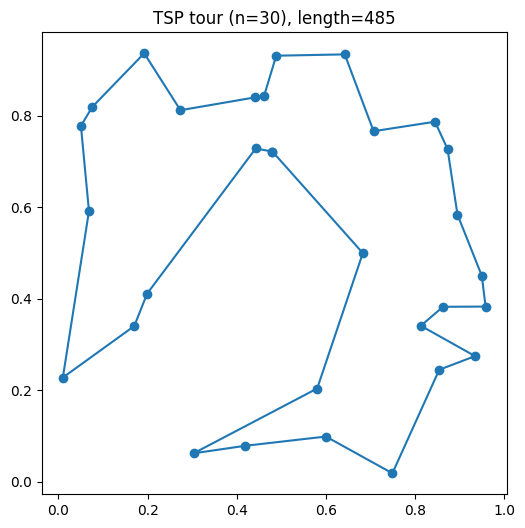

In [6]:
# medium_tsp.py

import numpy as np
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import matplotlib.pyplot as plt

# 1. Generate random 30 points in [0,1]^2
n = 30
points = np.random.rand(n, 2)
# Build integer distance matrix
dist_matrix = np.rint(
    np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2) * 100
).astype(int)

# 2. Set up manager & model
manager = pywrapcp.RoutingIndexManager(n, 1, 0)  # one vehicle, depot at 0
routing = pywrapcp.RoutingModel(manager)

# 3. Register distance callback
def dist_cb(i, j):
    return dist_matrix[manager.IndexToNode(i), manager.IndexToNode(j)]
cid = routing.RegisterTransitCallback(dist_cb)
routing.SetArcCostEvaluatorOfAllVehicles(cid)

# 4. Solve with a time limit
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.time_limit.seconds = 10
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
solution = routing.SolveWithParameters(search_params)

# 5. Extract tour
tour = []
idx = routing.Start(0)
while not routing.IsEnd(idx):
    tour.append(manager.IndexToNode(idx))
    idx = solution.Value(routing.NextVar(idx))
tour.append(tour[0])

# 6. Plot
xs, ys = points[tour, 0], points[tour, 1]
plt.figure(figsize=(6,6))
plt.plot(xs, ys, 'o-')
plt.title(f'TSP tour (n={n}), length={solution.ObjectiveValue()}')
plt.show()


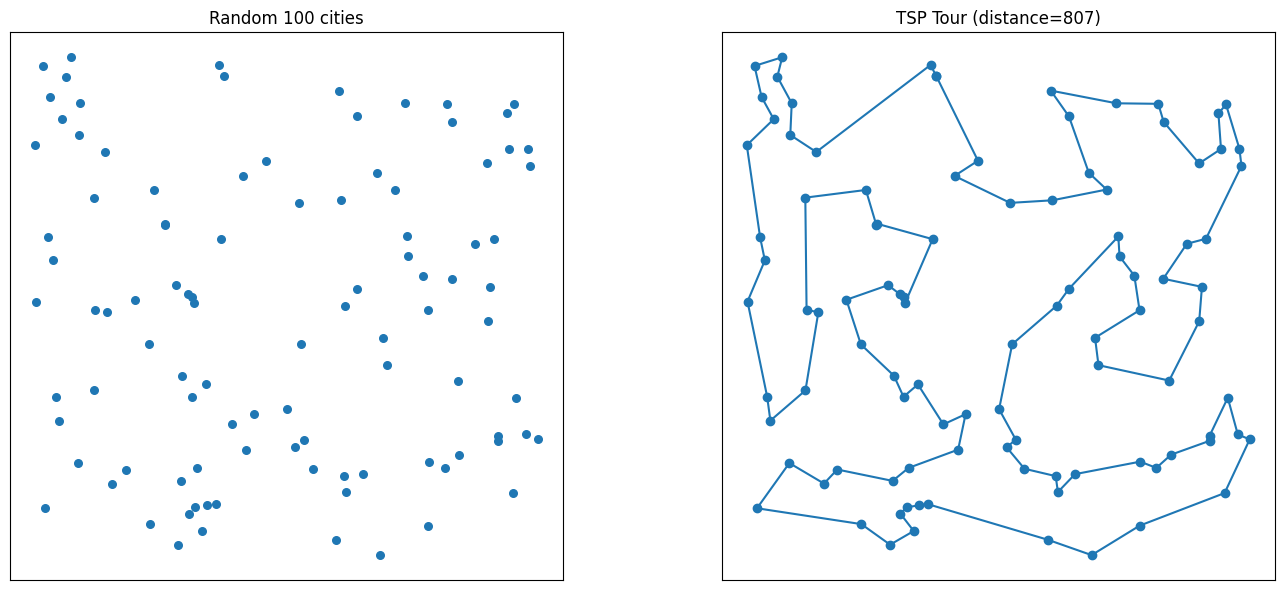

In [ ]:
# medium_tsp_side_by_side.py
''''
summary
This script generates a random set of points, computes the TSP tour using OR-Tools, and visualizes the results in a side-by-side plot.'''
import numpy as np
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Generate random 30 points in [0,1]^2
n = 100
points = np.random.rand(n, 2)

# 2. Build integer distance matrix
dist_matrix = np.rint(
    np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2) * 100
).astype(int)

# 3. Set up OR-Tools manager & model
manager = pywrapcp.RoutingIndexManager(n, 1, 0)  # 1 vehicle, depot at index 0
routing = pywrapcp.RoutingModel(manager)

# 4. Register distance callback
def dist_cb(i, j):
    return dist_matrix[manager.IndexToNode(i), manager.IndexToNode(j)]
cid = routing.RegisterTransitCallback(dist_cb)
routing.SetArcCostEvaluatorOfAllVehicles(cid)

# 5. Solve with a 10-second limit
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.time_limit.seconds = 10
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
solution = routing.SolveWithParameters(search_params)

# 6. Extract the tour sequence
tour = []
idx = routing.Start(0)
while not routing.IsEnd(idx):
    tour.append(manager.IndexToNode(idx))
    idx = solution.Value(routing.NextVar(idx))
tour.append(tour[0])  # return to start

# 7. Prepare coordinates for plotting the tour
xs_tour = points[tour, 0]
ys_tour = points[tour, 1]

# 8. Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

# 8a. Raw points only
ax1.scatter(points[:, 0], points[:, 1], s=30)
ax1.set_title(f'Random {n} cities')
ax1.set_aspect('equal')
ax1.set_xticks([]); ax1.set_yticks([])

# 8b. Points + Tour
ax2.plot(xs_tour, ys_tour, 'o-')
ax2.set_title(f'TSP Tour (distance={solution.ObjectiveValue()})')
ax2.set_aspect('equal')
ax2.set_xticks([]); ax2.set_yticks([])

plt.tight_layout()
plt.show()


In [1]:
(976 - 807) / 807

0.2094175960346964

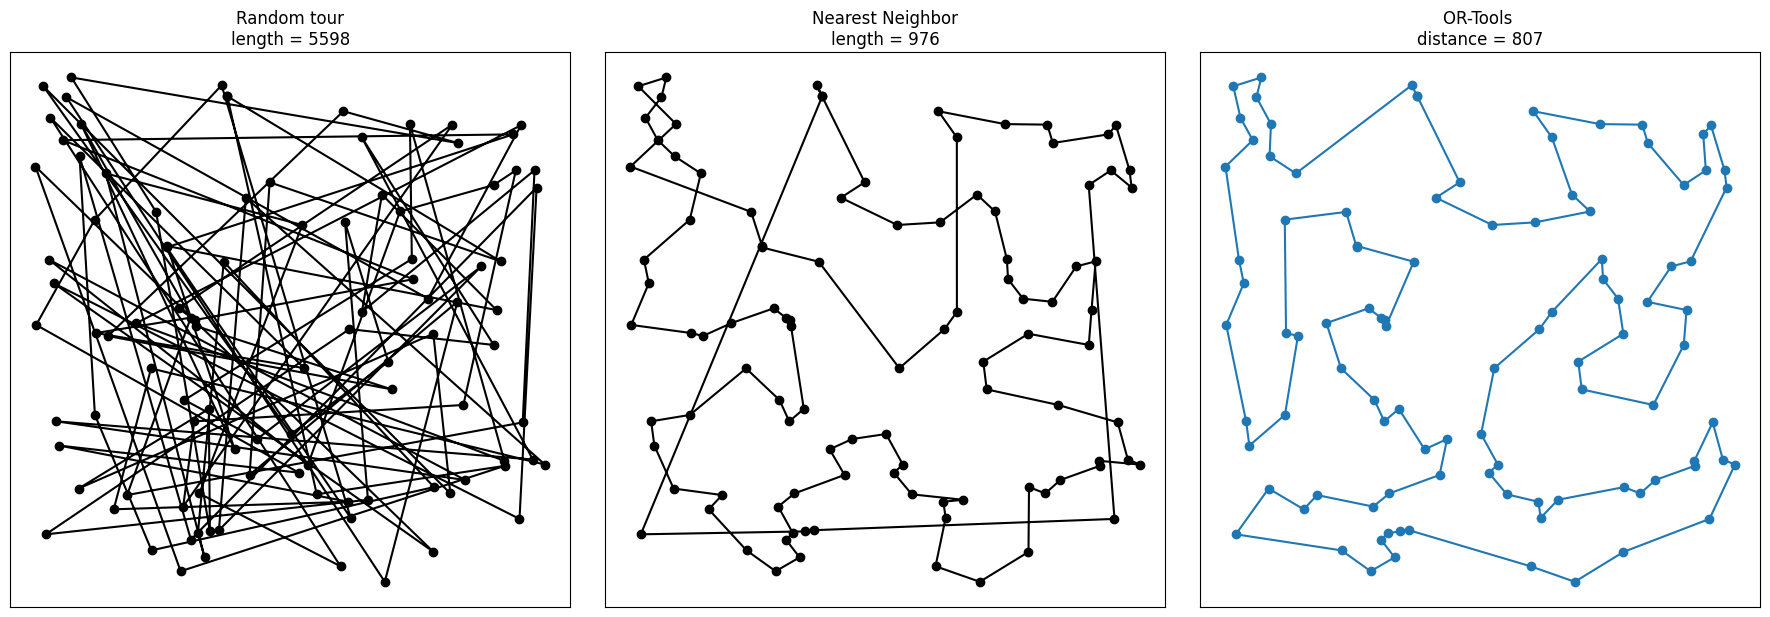

In [40]:
# medium_tsp_three_tours.py

import numpy as np
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100
points = np.random.rand(n, 2)

# Build integer distance matrix
dist_matrix = np.rint(
    np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2) * 100
).astype(int)

# 1) OR-Tools solution (treated as optimal here)
manager = pywrapcp.RoutingIndexManager(n, 1, 0)
routing = pywrapcp.RoutingModel(manager)

def dist_cb(i, j):
    return dist_matrix[manager.IndexToNode(i), manager.IndexToNode(j)]

cid = routing.RegisterTransitCallback(dist_cb)
routing.SetArcCostEvaluatorOfAllVehicles(cid)

search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.time_limit.seconds = 10
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)

solution = routing.SolveWithParameters(search_params)
opt_tour = []
idx = routing.Start(0)
while not routing.IsEnd(idx):
    opt_tour.append(manager.IndexToNode(idx))
    idx = solution.Value(routing.NextVar(idx))
opt_tour.append(opt_tour[0])
opt_len = solution.ObjectiveValue()

# 2) Nearest-Neighbor heuristic
def nn_tour(dist):
    unvisited = set(range(1, n))
    tour = [0]
    while unvisited:
        last = tour[-1]
        nxt = min(unvisited, key=lambda x: dist[last, x])
        tour.append(nxt)
        unvisited.remove(nxt)
    tour.append(0)
    return tour

nn = nn_tour(dist_matrix)
nn_len = sum(dist_matrix[nn[i], nn[i+1]] for i in range(len(nn)-1))

# 3) Random tour
rand_seq = [0] + list(np.random.permutation(range(1, n))) + [0]
rand_len = sum(dist_matrix[rand_seq[i], rand_seq[i+1]] for i in range(len(rand_seq)-1))

# Plot them side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

# Random tour
axes[0].scatter(points[:, 0], points[:, 1], s=10)
axes[0].plot(points[rand_seq, 0], points[rand_seq, 1], 'o-', color='black')
axes[0].set_title(f'Random tour\nlength = {rand_len}')
axes[0].set_aspect('equal')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Nearest-Neighbor tour
axes[1].scatter(points[:, 0], points[:, 1], s=10)
axes[1].plot(points[nn, 0], points[nn, 1], 'o-', color='black')
axes[1].set_title(f'Nearest Neighbor\nlength = {nn_len}')
axes[1].set_aspect('equal')
axes[1].set_xticks([]); axes[1].set_yticks([])

# OR-Tools “optimal” tour
axes[2].scatter(points[:, 0], points[:, 1], s=10)
axes[2].plot(points[opt_tour, 0], points[opt_tour, 1], 'o-')
axes[2].set_title(f'OR-Tools \ndistance = {opt_len}')
axes[2].set_aspect('equal')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.show()


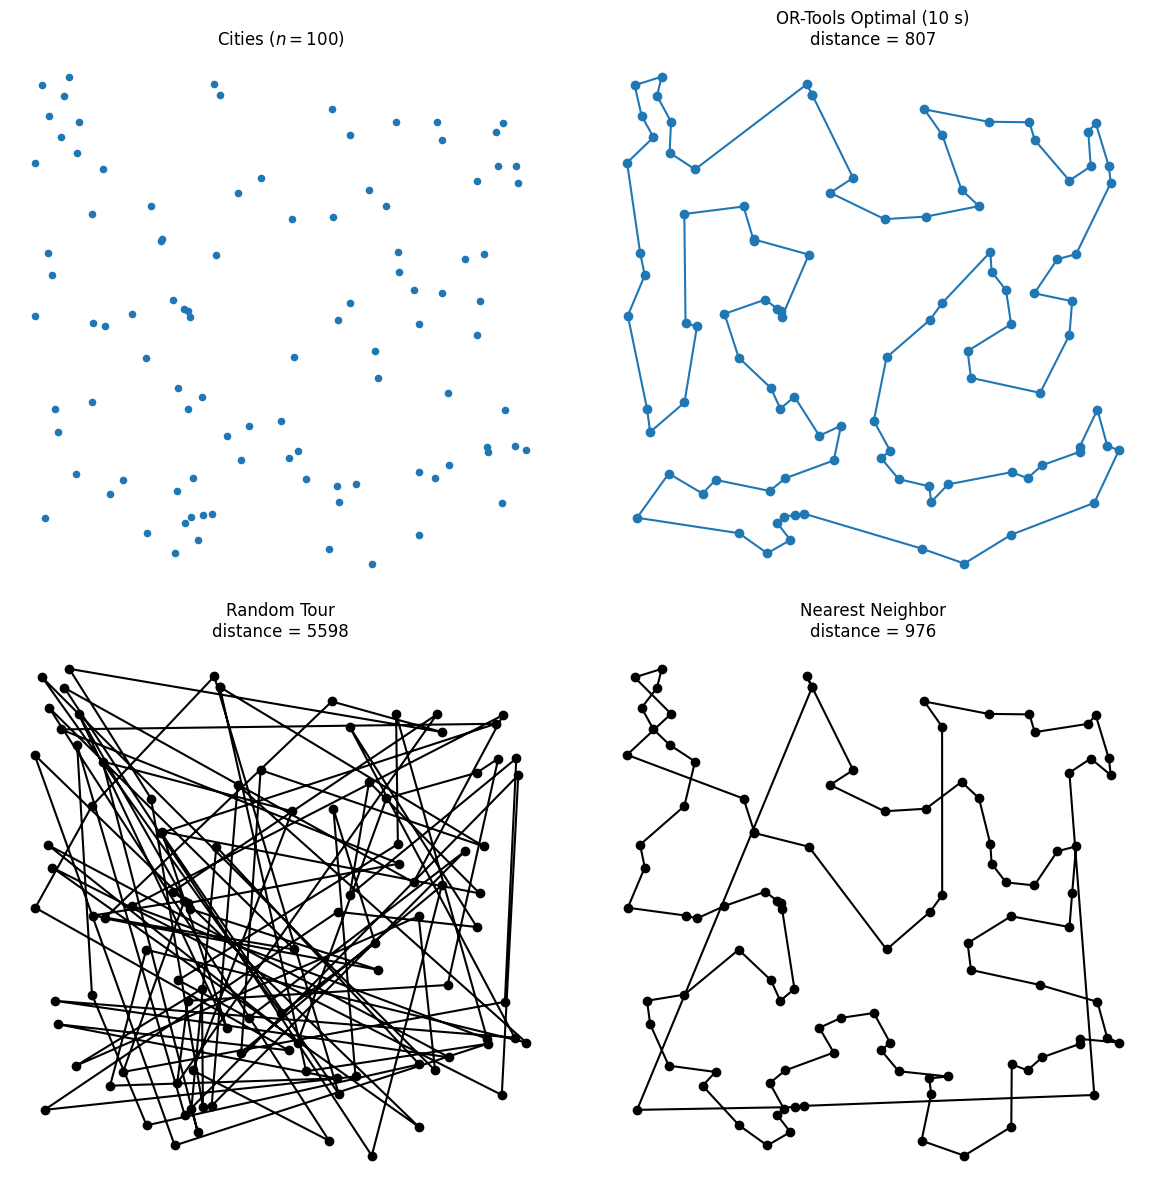

In [43]:
# medium_tsp_2x2.py

import numpy as np
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import matplotlib.pyplot as plt

# 1. Generate random points
np.random.seed(42)
n = 100
points = np.random.rand(n, 2)

# 2. Build integer distance matrix
dist_matrix = np.rint(
    np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2) * 100
).astype(int)

# 3. OR-Tools solution (10 s time limit)
manager = pywrapcp.RoutingIndexManager(n, 1, 0)
routing = pywrapcp.RoutingModel(manager)

def dist_cb(i, j):
    return dist_matrix[manager.IndexToNode(i), manager.IndexToNode(j)]

cid = routing.RegisterTransitCallback(dist_cb)
routing.SetArcCostEvaluatorOfAllVehicles(cid)

params = pywrapcp.DefaultRoutingSearchParameters()
params.time_limit.seconds = 10
params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
solution = routing.SolveWithParameters(params)

opt_tour = []
if solution:
    idx = routing.Start(0)
    while not routing.IsEnd(idx):
        opt_tour.append(manager.IndexToNode(idx))
        idx = solution.Value(routing.NextVar(idx))
    opt_tour.append(opt_tour[0])
    opt_len = solution.ObjectiveValue()
else:
    raise RuntimeError("No solution found!")

# 4. Nearest-Neighbor heuristic
def nn_tour(dist):
    unvisited = set(range(1, n))
    tour = [0]
    while unvisited:
        last = tour[-1]
        nxt = min(unvisited, key=lambda x: dist[last, x])
        tour.append(nxt)
        unvisited.remove(nxt)
    tour.append(0)
    return tour

nn = nn_tour(dist_matrix)
nn_len = sum(dist_matrix[nn[i], nn[i+1]] for i in range(len(nn)-1))

# 5. Random tour
rand_seq = [0] + list(np.random.permutation(range(1, n))) + [0]
rand_len = sum(
    dist_matrix[rand_seq[i], rand_seq[i+1]] 
    for i in range(len(rand_seq)-1)
)

# 6. Plot 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12), tight_layout=True)

# Top-left: cities only
axes[0, 0].scatter(points[:, 0], points[:, 1], s=20)
axes[0, 0].set_title(f'Cities ($n={n}$)')
axes[0, 0].set_aspect('equal')
axes[0, 0].axis('off')

# Top-right: OR-Tools optimal tour
axes[0, 1].scatter(points[:, 0], points[:, 1], s=20)
axes[0, 1].plot(points[opt_tour, 0], points[opt_tour, 1], 'o-')
axes[0, 1].set_title(f'OR-Tools Optimal (10 s)\ndistance = {opt_len}')
axes[0, 1].set_aspect('equal')
axes[0, 1].axis('off')

# Bottom-left: Random tour
axes[1, 0].scatter(points[:, 0], points[:, 1], s=20)
axes[1, 0].plot(points[rand_seq, 0], points[rand_seq, 1], 'o-', color='black')
axes[1, 0].set_title(f'Random Tour\ndistance = {rand_len}')
axes[1, 0].set_aspect('equal')
axes[1, 0].axis('off')

# Bottom-right: Nearest Neighbor tour
axes[1, 1].scatter(points[:, 0], points[:, 1], s=20)
axes[1, 1].plot(points[nn, 0], points[nn, 1], 'o-', color='black')
axes[1, 1].set_title(f'Nearest Neighbor\ndistance = {nn_len}')
axes[1, 1].set_aspect('equal')
axes[1, 1].axis('off')

plt.show()


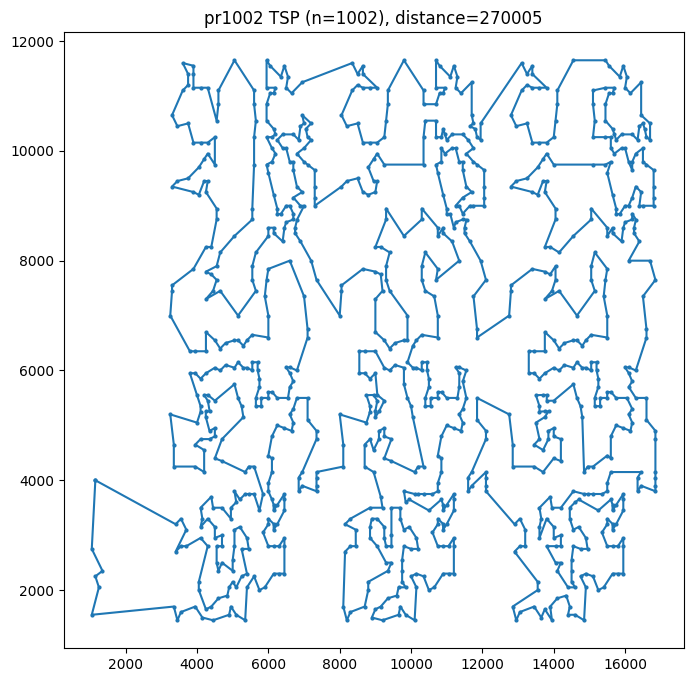

In [53]:
# large_pr1002.py

import math
import numpy as np
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import matplotlib.pyplot as plt

def read_tsplib(filename):
    coords = []
    with open(filename) as f:
        for line in f:
            if line.strip() == "NODE_COORD_SECTION":
                break
        for line in f:
            if line.strip() == "EOF":
                break
            parts = line.split()
            coords.append((float(parts[1]), float(parts[2])))
    return np.array(coords)

# 1. Load pr1002 coordinates
points = read_tsplib("pr1002.tsp")  # download from https://raw.githubusercontent.com/coin-or/jorlib/refs/heads/master/jorlib-core/src/test/resources/tspLib/tsp/pr1002.tsp
n = len(points)

# 2. Build distance matrix (Euclidean)
dist_matrix = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        dx, dy = points[i] - points[j]
        dist_matrix[i, j] = int(round(math.hypot(dx, dy)))

# 3. OR-Tools model
manager = pywrapcp.RoutingIndexManager(n, 1, 0)
routing = pywrapcp.RoutingModel(manager)

def dist_cb(i, j):
    return dist_matrix[manager.IndexToNode(i), manager.IndexToNode(j)]
cid = routing.RegisterTransitCallback(dist_cb)
routing.SetArcCostEvaluatorOfAllVehicles(cid)

# 4. Solve with a 70 s limit
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.time_limit.seconds = 70
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
solution = routing.SolveWithParameters(search_params)

# 5. Extract & plot
tour, idx = [], routing.Start(0)
while not routing.IsEnd(idx):
    tour.append(manager.IndexToNode(idx))
    idx = solution.Value(routing.NextVar(idx))
tour.append(tour[0])

xs, ys = points[tour, 0], points[tour, 1]
plt.figure(figsize=(8,8))
plt.plot(xs, ys, 'o-', markersize=2)
plt.title(f"pr1002 TSP (n={n}), distance={solution.ObjectiveValue()}")
plt.show()


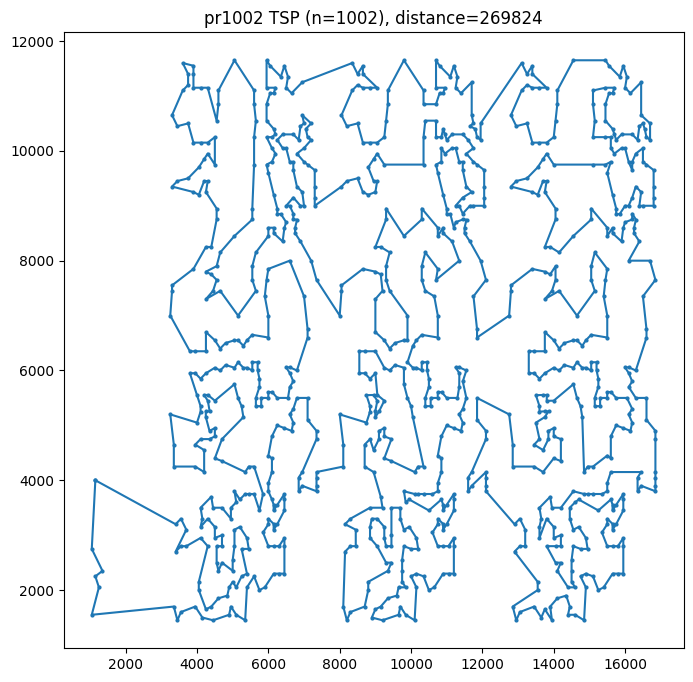

In [52]:
# large_pr1002.py

import math
import numpy as np
from ortools.constraint_solver import routing_enums_pb2, pywrapcp
import matplotlib.pyplot as plt

def read_tsplib(filename):
    coords = []
    with open(filename) as f:
        for line in f:
            if line.strip() == "NODE_COORD_SECTION":
                break
        for line in f:
            if line.strip() == "EOF":
                break
            parts = line.split()
            coords.append((float(parts[1]), float(parts[2])))
    return np.array(coords)

# 1. Load pr1002 coordinates
points = read_tsplib("pr1002.tsp")  # download from https://raw.githubusercontent.com/coin-or/jorlib/refs/heads/master/jorlib-core/src/test/resources/tspLib/tsp/pr1002.tsp
n = len(points)

# 2. Build distance matrix (Euclidean)
dist_matrix = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        dx, dy = points[i] - points[j]
        dist_matrix[i, j] = int(round(math.hypot(dx, dy)))

# 3. OR-Tools model
manager = pywrapcp.RoutingIndexManager(n, 1, 0)
routing = pywrapcp.RoutingModel(manager)

def dist_cb(i, j):
    return dist_matrix[manager.IndexToNode(i), manager.IndexToNode(j)]
cid = routing.RegisterTransitCallback(dist_cb)
routing.SetArcCostEvaluatorOfAllVehicles(cid)

# 4. Solve with a 60 s limit
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.time_limit.seconds = 60


# ========== IGNORE =========
# turn on a metaheuristic to improve that initial solution
search_params.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
# optionally, log progress
# search_params.log_search = True
# -----------------
solution = routing.SolveWithParameters(search_params)

# 5. Extract & plot
tour, idx = [], routing.Start(0)
while not routing.IsEnd(idx):
    tour.append(manager.IndexToNode(idx))
    idx = solution.Value(routing.NextVar(idx))
tour.append(tour[0])

xs, ys = points[tour, 0], points[tour, 1]
plt.figure(figsize=(8,8))
plt.plot(xs, ys, 'o-', markersize=2)
plt.title(f"pr1002 TSP (n={n}), distance={solution.ObjectiveValue()}")
plt.show()
